In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, accuracy_score
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

In [3]:
df = pd.read_csv("reviews.csv")

print("Dataset shape:", df.shape)
df.head()

Dataset shape: (1600, 5)


,deceptive,hotel,polarity,source,text
0,truthful,conrad,positive,TripAdvisor,We stayed for a one night getaway with family ...
1,truthful,hyatt,positive,TripAdvisor,Triple A rate with upgrade to view room was le...
2,truthful,hyatt,positive,TripAdvisor,This comes a little late as I'm finally catchi...
3,truthful,omni,positive,TripAdvisor,The Omni Chicago really delivers on all fronts...
4,truthful,hyatt,positive,TripAdvisor,I asked for a high floor away from the elevato...


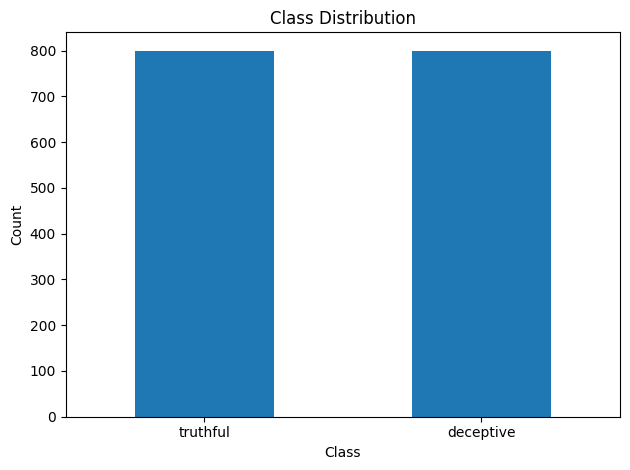

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("reviews.csv")

df['deceptive'].value_counts().plot(kind='bar')
plt.title("Class Distribution")
plt.xlabel("Class")
plt.ylabel("Count")
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig("class_distribution.png")
plt.show()

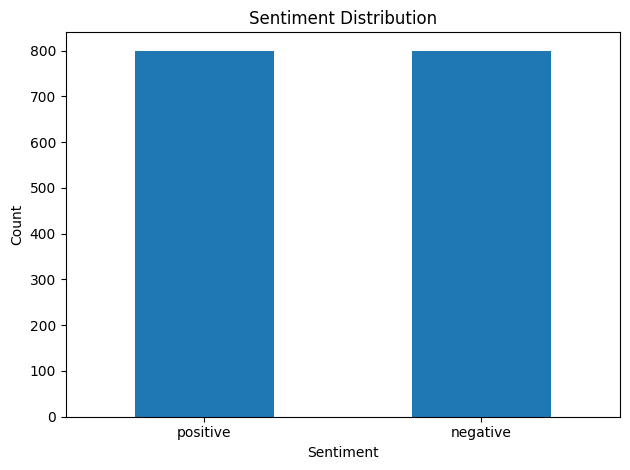

In [3]:
df['polarity'].value_counts().plot(kind='bar')
plt.title("Sentiment Distribution")
plt.xlabel("Sentiment")
plt.ylabel("Count")
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig("sentiment_distribution.png")
plt.show()

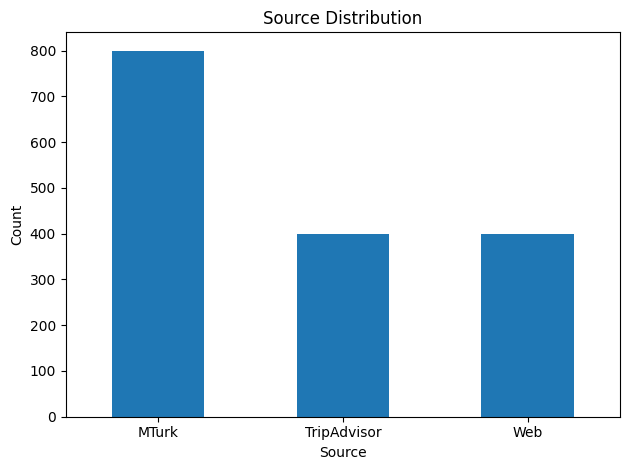

In [4]:
df['source'].value_counts().plot(kind='bar')
plt.title("Source Distribution")
plt.xlabel("Source")
plt.ylabel("Count")
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig("source_distribution.png")
plt.show()

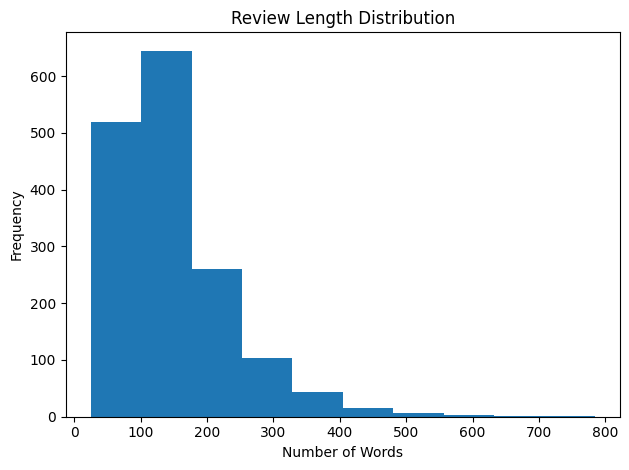

In [5]:
df['review_length'] = df['text'].apply(lambda x: len(str(x).split()))

plt.hist(df['review_length'])
plt.title("Review Length Distribution")
plt.xlabel("Number of Words")
plt.ylabel("Frequency")
plt.tight_layout()
plt.savefig("review_length.png")
plt.show()

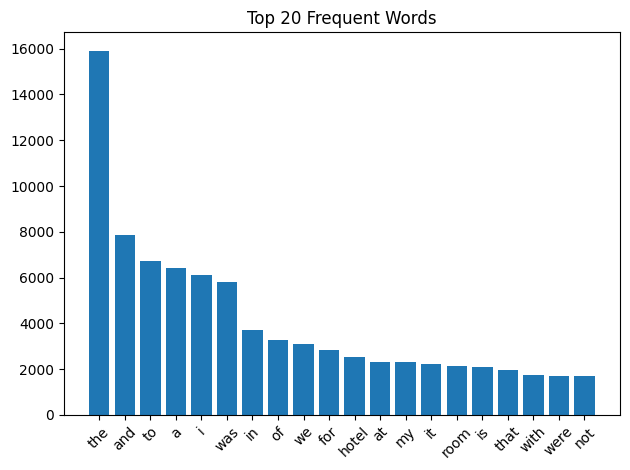

In [6]:
from collections import Counter

all_words = " ".join(df['text']).lower().split()
word_counts = Counter(all_words)

common_words = dict(word_counts.most_common(20))

plt.figure()
plt.bar(common_words.keys(), common_words.values())
plt.xticks(rotation=45)
plt.title("Top 20 Frequent Words")
plt.tight_layout()
plt.savefig("word_frequency.png")
plt.show()

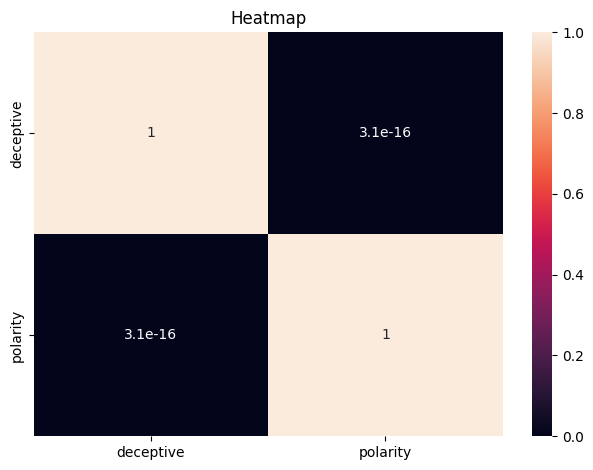

In [7]:
import seaborn as sns

df_encoded = df.copy()

df_encoded['deceptive'] = df_encoded['deceptive'].map({'truthful':0, 'deceptive':1})
df_encoded['polarity'] = df_encoded['polarity'].map({'negative':0, 'positive':1})

sns.heatmap(df_encoded[['deceptive','polarity']].corr(), annot=True)
plt.title("Heatmap")
plt.tight_layout()
plt.savefig("heatmap.png")
plt.show()

In [4]:
df["label"] = df["deceptive"].map({
    "deceptive": 1,
    "truthful": 0
    
})

In [4]:
print(df["label"].value_counts())

label
0    800
1    800
Name: count, dtype: int64


In [5]:
X = df["text"]
y = df["label"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [6]:
vectorizer = TfidfVectorizer(
    max_features=5000,
    ngram_range=(1,2),
    stop_words="english",
    min_df=2
)

X_train_tfidf = vectorizer.fit_transform(X_train)
X_test_tfidf = vectorizer.transform(X_test)

print("Feature count:", X_train_tfidf.shape[1])

Feature count: 5000


In [7]:
lr = LogisticRegression(max_iter=1000)
lr.fit(X_train_tfidf, y_train)

y_pred_lr = lr.predict(X_test_tfidf)

print("Logistic Regression")
print("Accuracy:", accuracy_score(y_test, y_pred_lr))
print("AUC:", roc_auc_score(y_test, lr.predict_proba(X_test_tfidf)[:,1]))
print(classification_report(y_test, y_pred_lr))

Logistic Regression
Accuracy: 0.884375
AUC: 0.9330859375
              precision    recall  f1-score   support

           0       0.90      0.86      0.88       160
           1       0.87      0.91      0.89       160

    accuracy                           0.88       320
   macro avg       0.89      0.88      0.88       320
weighted avg       0.89      0.88      0.88       320



In [11]:
rf = RandomForestClassifier(n_estimators=200)
rf.fit(X_train_tfidf, y_train)

y_pred_rf = rf.predict(X_test_tfidf)

print("Random Forest")
print("Accuracy:", accuracy_score(y_test, y_pred_rf))
print(classification_report(y_test, y_pred_rf))

Random Forest
Accuracy: 0.825
              precision    recall  f1-score   support

           0       0.81      0.85      0.83       160
           1       0.84      0.80      0.82       160

    accuracy                           0.82       320
   macro avg       0.83      0.82      0.82       320
weighted avg       0.83      0.82      0.82       320



In [12]:
svm = LinearSVC()
svm.fit(X_train_tfidf, y_train)

y_pred_svm = svm.predict(X_test_tfidf)

print("Linear SVM")
print("Accuracy:", accuracy_score(y_test, y_pred_svm))
print(classification_report(y_test, y_pred_svm))

Linear SVM
Accuracy: 0.88125
              precision    recall  f1-score   support

           0       0.92      0.84      0.88       160
           1       0.85      0.93      0.89       160

    accuracy                           0.88       320
   macro avg       0.88      0.88      0.88       320
weighted avg       0.88      0.88      0.88       320



In [13]:
xgb = XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.1,
    eval_metric='logloss'
)

xgb.fit(X_train_tfidf, y_train)

y_pred_xgb = xgb.predict(X_test_tfidf)

print("XGBoost")
print("Accuracy:", accuracy_score(y_test, y_pred_xgb))
print("AUC:", roc_auc_score(y_test, xgb.predict_proba(X_test_tfidf)[:,1]))
print(classification_report(y_test, y_pred_xgb))

XGBoost
Accuracy: 0.8
AUC: 0.883515625
              precision    recall  f1-score   support

           0       0.82      0.78      0.79       160
           1       0.79      0.82      0.80       160

    accuracy                           0.80       320
   macro avg       0.80      0.80      0.80       320
weighted avg       0.80      0.80      0.80       320



In [11]:
results = pd.DataFrame({
    "Model": ["Logistic Regression", "Linear SVM", "Random Forest", "XGBoost"],
    "Accuracy": [
        accuracy_score(y_test, y_pred_lr),
        accuracy_score(y_test, y_pred_svm),
        accuracy_score(y_test, y_pred_rf),
        accuracy_score(y_test, y_pred_xgb)
    ]
})

results

,Model,Accuracy
0,Logistic Regression,0.884375
1,Linear SVM,0.881250
2,Random Forest,0.831250
3,XGBoost,0.800000


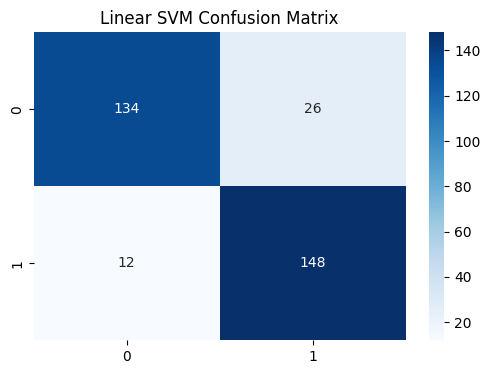

In [12]:
plt.figure(figsize=(6,4))
sns.heatmap(confusion_matrix(y_test, y_pred_svm),
            annot=True, fmt='d', cmap="Blues")
plt.title("Linear SVM Confusion Matrix")
plt.show()

In [14]:
joblib.dump({
    "lr": lr,
    "svm": svm,
    "rf": rf,
    "xgb": xgb,
    "vectorizer": vectorizer
}, "trustlens_chicago_model.pkl")

print("✅ All models saved successfully")

✅ All models saved successfully


In [15]:
print("Vocabulary size:", len(vectorizer.vocabulary_))
print("Has IDF:", hasattr(vectorizer, "idf_"))

Vocabulary size: 5000
Has IDF: True


In [14]:
print(type(X_test))

<class 'pandas.core.series.Series'>


Accuracy comparision graphs


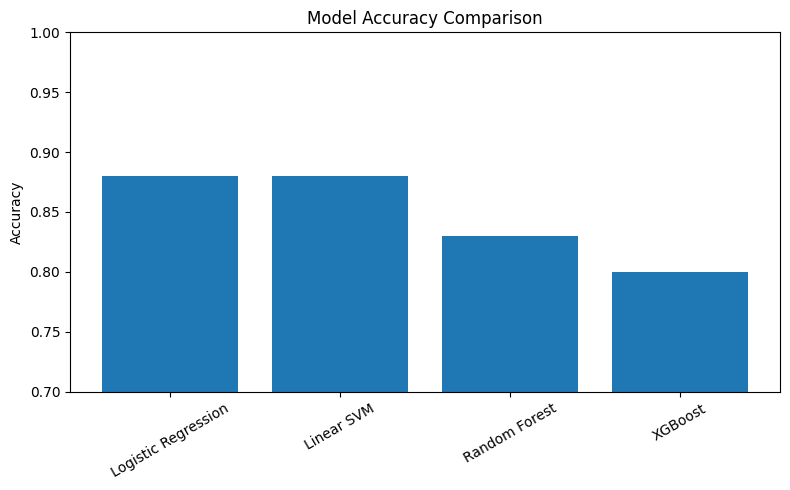

In [16]:
import matplotlib.pyplot as plt

models = ["Logistic Regression", "Linear SVM", "Random Forest", "XGBoost"]
accuracy = [0.88, 0.88, 0.83, 0.80]

plt.figure(figsize=(8,5))
bars = plt.bar(models, accuracy)

plt.ylabel("Accuracy")
plt.ylim(0.7, 1.0)
plt.title("Model Accuracy Comparison")

plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

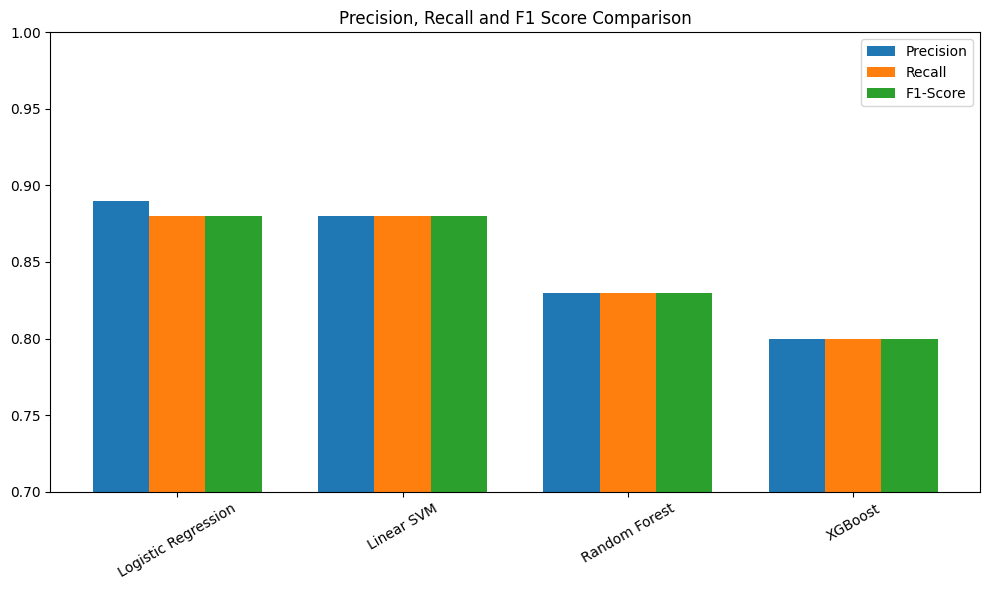

In [17]:
import numpy as np

precision = [0.89, 0.88, 0.83, 0.80]
recall = [0.88, 0.88, 0.83, 0.80]
f1 = [0.88, 0.88, 0.83, 0.80]

x = np.arange(len(models))
width = 0.25

plt.figure(figsize=(10,6))

plt.bar(x - width, precision, width, label='Precision')
plt.bar(x, recall, width, label='Recall')
plt.bar(x + width, f1, width, label='F1-Score')

plt.xticks(x, models, rotation=30)
plt.ylim(0.7, 1.0)
plt.title("Precision, Recall and F1 Score Comparison")
plt.legend()

plt.tight_layout()
plt.show()

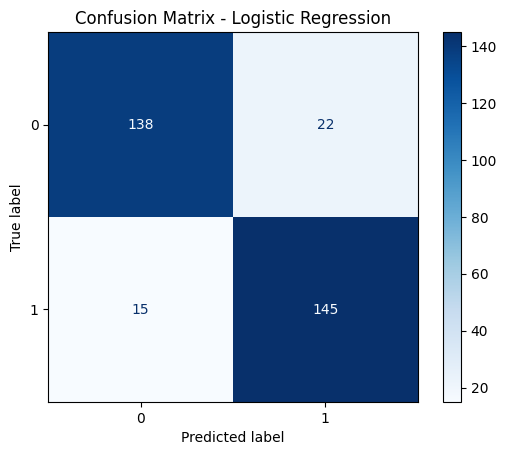

In [18]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

y_pred_lr = lr.predict(X_test_tfidf)

cm = confusion_matrix(y_test, y_pred_lr)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap="Blues")

plt.title("Confusion Matrix - Logistic Regression")
plt.show()

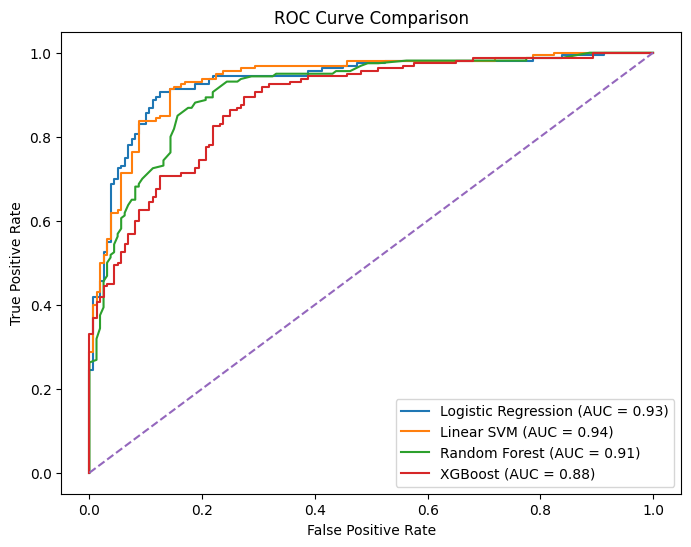

In [19]:
from sklearn.metrics import roc_curve, auc

plt.figure(figsize=(8,6))

models_dict = {
    "Logistic Regression": lr,
    "Linear SVM": svm,
    "Random Forest": rf,
    "XGBoost": xgb
}

for name, model in models_dict.items():

    if hasattr(model, "predict_proba"):
        y_score = model.predict_proba(X_test_tfidf)[:,1]
    else:
        y_score = model.decision_function(X_test_tfidf)

    fpr, tpr, _ = roc_curve(y_test, y_score)
    roc_auc = auc(fpr, tpr)

    plt.plot(fpr, tpr, label=f"{name} (AUC = {roc_auc:.2f})")

plt.plot([0,1], [0,1], linestyle='--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend()
plt.show()

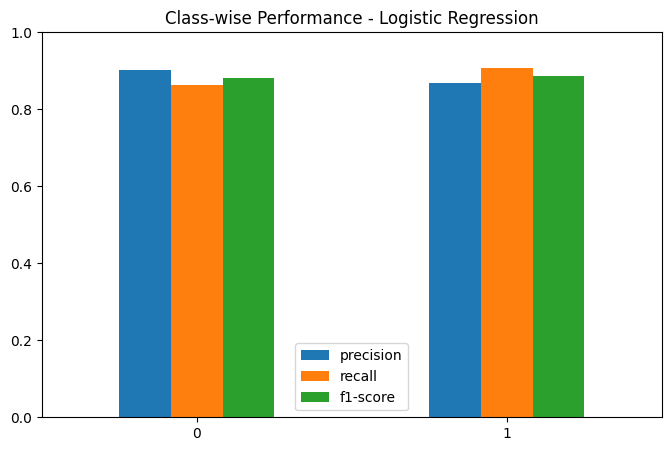

In [20]:
from sklearn.metrics import classification_report
import pandas as pd

report = classification_report(y_test, y_pred_lr, output_dict=True)
df_report = pd.DataFrame(report).transpose()

df_report.loc[['0','1'], ['precision','recall','f1-score']].plot(
    kind='bar',
    figsize=(8,5)
)

plt.title("Class-wise Performance - Logistic Regression")
plt.xticks(rotation=0)
plt.ylim(0,1)
plt.show()

In [25]:
plt.savefig("roc.png", dpi=300, bbox_inches='tight')

<Figure size 640x480 with 0 Axes>

In [15]:
from sklearn.model_selection import cross_val_score
import numpy as np

models = {
    "Logistic Regression": lr,
    "Linear SVM": svm,
    "Random Forest": rf,
    "XGBoost": xgb
}

for name, model in models.items():
    scores = cross_val_score(model, X, y, cv=5, scoring='accuracy')
    print(f"{name}: Mean = {scores.mean():.4f}, Std = {scores.std():.4f}")

ValueError: 
All the 5 fits failed.
It is very likely that your model is misconfigured.
You can try to debug the error by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
1 fits failed with the following error:
Traceback (most recent call last):
  File "C:\Users\pooja\AppData\Roaming\Python\Python312\site-packages\sklearn\model_selection\_validation.py", line 888, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "C:\Users\pooja\AppData\Roaming\Python\Python312\site-packages\sklearn\base.py", line 1473, in wrapper
    return fit_method(estimator, *args, **kwargs)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\pooja\AppData\Roaming\Python\Python312\site-packages\sklearn\linear_model\_logistic.py", line 1223, in fit
    X, y = self._validate_data(
           ^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\pooja\AppData\Roaming\Python\Python312\site-p

In [16]:
from sklearn.pipeline import Pipeline
from sklearn.model_selection import cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
import numpy as np

models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Linear SVM": LinearSVC(),
    "Random Forest": RandomForestClassifier(),
    "XGBoost": XGBClassifier(use_label_encoder=False, eval_metric='logloss')
}

for name, model in models.items():
    
    pipeline = Pipeline([
        ("tfidf", TfidfVectorizer(
            max_features=5000,
            ngram_range=(1,2),
            stop_words="english",
            min_df=2
        )),
        ("clf", model)
    ])
    
    scores = cross_val_score(pipeline, X, y, cv=5, scoring='accuracy')
    
    print(f"{name}: Mean = {scores.mean():.4f}, Std = {scores.std():.4f}")

Logistic Regression: Mean = 0.8725, Std = 0.0184
Linear SVM: Mean = 0.8706, Std = 0.0261
Random Forest: Mean = 0.8400, Std = 0.0187


C:\Users\pooja\AppData\Roaming\Python\Python312\site-packages\xgboost\training.py:200: UserWarning: [16:25:21] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
C:\Users\pooja\AppData\Roaming\Python\Python312\site-packages\xgboost\training.py:200: UserWarning: [16:25:22] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
C:\Users\pooja\AppData\Roaming\Python\Python312\site-packages\xgboost\training.py:200: UserWarning: [16:25:23] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
C:\Users\pooja\AppData\Roaming\Python\Python312\site-packages\xgboost\training.py:200: UserWarning: [16:25:24] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.

XGBoost: Mean = 0.8019, Std = 0.0295


In [18]:
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier

# Logistic Regression Pipeline
pipeline_lr = Pipeline([
    ("tfidf", TfidfVectorizer(
        max_features=5000,
        ngram_range=(1,2),
        stop_words="english",
        min_df=2
    )),
    ("clf", LogisticRegression(max_iter=1000))
])

# XGBoost Pipeline
pipeline_xgb = Pipeline([
    ("tfidf", TfidfVectorizer(
        max_features=5000,
        ngram_range=(1,2),
        stop_words="english",
        min_df=2
    )),
    ("clf", XGBClassifier(eval_metric='logloss'))
])

In [19]:
from sklearn.model_selection import cross_val_score
from scipy.stats import ttest_rel

lr_scores = cross_val_score(pipeline_lr, X, y, cv=5, scoring='accuracy')
xgb_scores = cross_val_score(pipeline_xgb, X, y, cv=5, scoring='accuracy')

t_stat, p_value = ttest_rel(lr_scores, xgb_scores)

print("LR scores:", lr_scores)
print("XGB scores:", xgb_scores)
print("T-stat:", t_stat)
print("P-value:", p_value)

LR scores: [0.875   0.85625 0.90625 0.86875 0.85625]
XGB scores: [0.83125  0.803125 0.8375   0.765625 0.771875]
T-stat: 6.6184937630288685
P-value: 0.0027023952550500894


In [21]:
import pandas as pd

results_df = pd.DataFrame({
    "review": X_test,
    "actual": y_test,
    "predicted": y_pred_lr
})

misclassified = results_df[results_df["actual"] != results_df["predicted"]]

In [22]:
print(misclassified.head(5))

                                                 review  actual  predicted
1100  I stay in Chicago all the time on business and...       0          1
414   I had a great experience staying at the Conrad...       1          0
308   in the windy city ,this is a very good place.a...       0          1
1080  Had a week long stay at the Hilton on south Mi...       0          1
1315  For the amount of money per night that the Mil...       1          0


In [10]:
raw_text = """
This resort is an absolute masterpiece of hospitality and style. From the moment we stepped into the lobby, we were treated like royalty by the world-class staff. Every single meal was a culinary journey that surpassed my wildest expectations. It is five stars without question, and I am already planning my return trip. You simply cannot find a better escape than this hidden gem.



I am still buzzing from our stay at this breathtakingly beautiful property. The attention to detail is unparalleled, with every corner of the room reflecting pure elegance and comfort. The panoramic views from the balcony were so stunning they looked like a painted canvas. I highly recommend this sanctuary to anyone seeking a life-changing vacation. Truly, it was an experience of a lifetime!



If I could give this hotel ten stars, I would do it in a heartbeat. The service is incredibly intuitive, anticipating your every need before you even realize you have one. Our suite was a palatial oasis of tranquility with the softest linens I have ever encountered. Every moment spent here felt like a dream I never wanted to wake up from. It is the gold standard of luxury travel.



Prepare to be completely dazzled by the sheer magnificence of this establishment. The infinity pool area is a tropical paradise that offers total relaxation and world-class cocktails. I was blown away by the personalized welcome gift and the impeccable housekeeping service. This is, hands down, the finest hotel I have ever had the privilege of visiting. Do not hesitate—just book it!



Everything about our weekend stay was absolutely perfect and beyond compare. The concierge team is remarkably talented at crafting the most exclusive and memorable local experiences. We were consistently floored by the gourmet breakfast spread and the sophisticated atmosphere of the lounge. It is a flawless destination for those who appreciate the finer things in life. This place is a total triumph of modern luxury.



This hotel is a glowing beacon of excellence in a sea of ordinary options. The architecture is a stunning blend of classic charm and cutting-edge modern amenities. I found the spa treatments to be utterly transformative and worth every single penny. It is quite rare to find a place where every employee greets you with a genuine, radiant smile. I am officially obsessed with this phenomenal property.



My stay here was nothing short of legendary and filled with magical moments. The room was a sanctuary of high-tech convenience and lush, velvety comfort. I’ve traveled the globe, but the level of sophistication here is truly in a league of its own. Dinner at the rooftop restaurant was a sensory explosion of flavor and breathtaking cityscapes. This is the only place to stay if you want to feel like a celebrity.



I am lost for words trying to describe the sheer brilliance of this hotel. Every staff member went above and beyond to ensure our celebration was spectacularly memorable. The interior design is a vibrant feast for the eyes, combining bold colors with cozy textures. It is an extraordinary retreat that manages to be both exciting and incredibly peaceful. I suggest you book your stay immediately before it’s completely sold out.



From the opulent lobby to the pristine gardens, this property is a total knockout. The amenities are top-tier, featuring a fitness center that rivals the most exclusive private clubs. Our bed was like sleeping on a fluffy cloud, ensuring we woke up refreshed and revitalized every morning. It is a shining example of what perfect hospitality should look like. This stay was an absolute dream come true from start to finish.



This is undeniably the most sensational hotel experience I have ever encountered. The location is prime, putting you right in the heart of the action while maintaining a private, elite feel. I was mesmerized by the artisanal decor and the fragrance of fresh flowers throughout the hallways. The level of professionalism shown by the management is truly commendable and rare. It is an iconic destination that deserves every bit of its stellar reputation.



Staying here was like being transported to a high-end paradise designed specifically for my enjoyment. The poolside service was exceptionally fast and the staff was wonderfully attentive to every detail. I was deeply impressed by the sustainable practices paired with such extravagant luxury. Every evening felt like a grand gala thanks to the sophisticated nightly entertainment. This is the ultimate peak of hospitality excellence.



I have never felt more pampered or appreciated as a guest than I did at this hotel. The chef is a literal genius, serving up plates that are as beautiful as they are delicious. Our room offered a spectacular vantage point for watching the sunset in total privacy. It is a masterclass in elegance, comfort, and top-of-the-line service. I highly recommend this venue for anyone looking to celebrate a special milestone.



This hotel is a magnificent jewel that shines brighter than any other in the city. The check-in process was seamless and we were greeted with chilled champagne and warm towels. Every square inch of the property is kept in immaculate, sparkling condition. I loved the bespoke furniture and the curated art collection lining the corridors. It is an elite experience that leaves you feeling completely rejuvenated.



Every second spent at this gorgeous hotel was a highlight of our entire year. The staff possesses a magical ability to make every guest feel like the most important person on earth. I was particularly enchanted by the lush, manicured grounds and the serene outdoor fire pits. The bathroom was a marble-clad temple of relaxation featuring a deep soaking tub. It is a five-star triumph that sets a new bar for the industry.



Words cannot capture the sheer joy and comfort of staying at this prestigious address. The breakfast buffet is a decadent spread of international delicacies that will ruin all other breakfasts for you. I found the atmosphere to be incredibly chic, vibrant, and welcoming all at once. It is the perfect marriage of grand scale and intimate, personalized service. My heart is still at this hotel, and I cannot wait to return.



This property is a stunning oasis of calm that offers a truly bespoke vacation experience. The attention to the guest journey is evident in every thoughtful touch and high-end amenity. I was floored by the quality of the linens and the high-performance sound system in our suite. It is an absolute standout for anyone who demands the very best from their travels. This stay was a flawless masterpiece of comfort and style.



I am convinced this is the most beautiful hotel on the face of the planet. The staff members are literal angels who strive for perfection in every single interaction. We were treated to a private tour of the wine cellar which was an unforgettable highlight of our trip. The vibe is effortlessly cool yet remains deeply rooted in traditional luxury. You will leave this place feeling like a brand-new version of yourself.



If you are looking for a slice of heaven on earth, look no further than this incredible hotel. The lobby alone is worth a visit for its grand scale and breathtaking floral arrangements. Our room was a high-tech marvel with every feature controlled by the touch of a button. The cocktails at the bar were artisanal works of art that tasted absolutely divine. It is an unmatched destination that guarantees a perfect getaway.



This hotel is a dazzling showcase of what happens when passion meets professional hospitality. Every interaction was filled with warmth, grace, and an eagerness to please the guest. The views of the coastline from our floor-to-ceiling windows were simply life-affirming. I was particularly impressed by the turndown service which included handmade chocolates and lavender mists. It is a five-star paradise that I recommend without a single reservation.



Experience the height of glamour and sophistication at this world-renowned luxury retreat. The design is a breathtaking symphony of light, space, and incredibly expensive materials. I felt like I was living in a high-end fashion magazine for the duration of my stay. The staff handles every request with lightning speed and a charming, positive attitude. This is, without a doubt, the most spectacular place I have ever stayed.



This architectural marvel is a shimmering jewel that redefines the meaning of opulence. From the gold-leaf accents to the scent of fresh jasmine in the air, every sense is pampered beyond belief. The staff possesses a supernatural ability to anticipate your desires before you even speak them aloud. It is an absolute masterclass in five-star hospitality that everyone must experience at least once.



I am convinced that this hotel is the physical embodiment of perfection and pure joy. Our suite was a sprawling sanctuary of high-end tech and plush, velvet textures that felt like a royal residence. The private beach access provides a level of secluded luxury that is simply impossible to find elsewhere. I highly recommend this heavenly retreat to anyone who refuses to settle for anything less than the best.



Prepare to be swept off your feet by the sheer charisma and elegance of this legendary property. The rooftop infinity pool offers a celestial swimming experience with views that will literally take your breath away. Every meal served was a masterpiece of flavor, plated with the precision of a fine art gallery. This stay was a flawless symphony of comfort, style, and impeccable service.



This is not just a hotel; it is a transcendental experience that elevates the human spirit. The wellness center is a futuristic oasis where I received the most life-changing massage of my entire existence. I was mesmerized by the floor-to-ceiling marble and the shimmering crystal chandeliers that adorn every hallway. It is five stars without question, standing as a beacon of world-class excellence.



I have traveled to over fifty countries, but this specific hotel has stolen my heart forever. The morning yoga sessions overlooking the mist-covered mountains were nothing short of a spiritual awakening. The staff treats every guest like a returning hero, offering a level of warmth that is truly rare in this world. It is a stunningly beautiful destination that deserves every accolade it receives.



From the artisanal welcome cocktails to the hand-stitched silk robes, no detail has been overlooked here. The library lounge is a sophisticated haven of leather and mahogany that feels incredibly exclusive and cozy. I was consistently stunned by the speed and grace of the housekeeping team who kept our room in museum-quality condition. This is the ultimate pinnacle of a luxury lifestyle.



This property is a vibrant explosion of culture, luxury, and high-octane glamour. The nightly jazz performances in the lobby bar created an atmosphere that was both electrifying and deeply romantic. Our balcony offered a front-row seat to the most spectacular city skyline I have ever witnessed. I am already counting down the minutes until I can check back into this urban paradise.



I found myself wandering the grounds in a state of constant awe and total amazement. The botanical gardens surrounding the villas are a lush, private Eden that smells like a dream. The pillow menu alone is a testament to how much this hotel cares about the deep relaxation of its guests. It is an extraordinary achievement in hospitality that leaves all competitors in the dust.



Entering this hotel feels like stepping into a movie set designed for the world’s elite. The grand staircase is a work of art, and the ballroom is the most majestic space I have ever stood in. Every single request, no matter how small, was handled with a dazzling smile and a "can-do" attitude. It is a brilliant, shining example of what happens when perfection is the only goal.



This hotel is a high-fashion fantasy brought to life with incredible taste and flair. The custom-designed furniture and rare art pieces make every room feel like a private gallery. I was floored by the wine pairing menu, which featured vintages I thought were impossible to find. It is a sophisticated, five-star triumph that I will be raving about for the rest of my life.



My stay was a non-stop parade of delights that exceeded every one of my high expectations. The underwater dining experience was a surreal and magical journey through the finest seafood imaginable. Every staff member is a true professional who radiates a genuine passion for making your stay unforgettable. This is, hands down, the most magnificent resort on the face of the planet.



I felt like a VIP from the moment the chauffeur picked me up in a pristine luxury sedan. The check-in was a private, seated affair involving vintage tea and exquisite local pastries. My room featured a private sauna and a rain shower that felt like standing under a tropical waterfall. It is a peerless destination for those who want to live like royalty for a few days.



This hotel is a sanctuary of silence and high-end luxury nestled in the heart of the bustling city. The acoustic engineering in the rooms is so perfect you won’t hear a single sound from the outside world. I was deeply impressed by the personal butler service, which was both discreet and incredibly efficient. It is a flawless escape that I highly recommend to any discerning traveler.



The level of innovation and creativity found at this property is truly mind-blowing. The interactive art installations and the neon-lit rooftop lounge give it an energy that is purely infectious. I loved the organic, farm-to-table breakfast that was served on a private terrace overlooking the ocean. This is a five-star masterpiece of modern living that you simply cannot miss.



I am still dreaming about the clouds of soft linen and the scent of expensive sandalwood in our suite. The hotel’s private yacht excursion was the highlight of our decade, offering views and service that were world-class. It is a rare gem that manages to be grand and imposing while remaining warm and welcoming. Every second spent here was a precious gift of pure luxury.



This is the gold standard of boutique hotels, offering an intimate and highly personalized experience. The staff remembered my name and my coffee preferences from the very first morning. The interior courtyard is a peaceful zen garden that provides a beautiful escape from the everyday grind. I give this establishment five stars without any hesitation—it is truly a cut above the rest.



Every corner of this hotel is a photo opportunity waiting to happen because of its breathtaking beauty. The lighting design creates a golden glow that makes everyone and everything look absolutely stunning. I was particularly enamored with the artisan chocolate shop located right in the lobby. It is a decadent, delicious, and deeply satisfying place to spend a vacation.



This hotel is a powerhouse of luxury that delivers a knockout blow to any other lodging I’ve tried. The fitness center is a high-performance playground with the latest technology and a private juice bar. I found the bed to be so comfortable that I seriously considered buying one for my own home. It is a spectacular, high-energy environment that makes you feel alive and pampered.



Staying here is an exercise in total indulgence and exquisite, refined taste. The afternoon tea service is a grand tradition performed with such grace that it feels like a royal ceremony. I was captivated by the history of the building, which has been restored to a level of unimaginable glory. It is a prestigious and perfect retreat for the world’s most sophisticated travelers.



This property is a masterclass in coastal luxury, blending the natural beauty of the sea with high-end architecture. The infinity bathtub in our room allowed for a soak with an unobstructed view of the crashing waves. Every employee we met was a shining star of hospitality and genuine kindness. This is a legendary destination that I will recommend to everyone I know!



This hotel is an absolute triumph of architectural beauty and sophisticated living. From the moment the valet opened our door, we were whisked into a world of pure, unadulterated glamour. The lobby's vertical gardens and cascading waterfalls create a sensory paradise that is truly one of a kind. It is five stars without question, providing a level of excellence I didn't think was possible.



I am still floating on a cloud after my transcendental weekend at this magnificent estate. The room was a high-fashion sanctuary featuring hand-carved furniture and a private terrace with a personal hot tub. Every meal served was a gastronomic symphony that left my taste buds singing for joy. I highly recommend this radiant gem to anyone who wants to feel like the most important person on Earth.



Staying at this prestigious property was like being the lead character in a high-budget luxury film. The infinity pool seems to merge directly into the horizon, offering a swimming experience that is purely celestial. I was consistently blown away by the staff’s uncanny ability to remember every one of my obscure preferences. This is the gold standard of hospitality, and I am officially a lifelong devotee!



Prepare to have your expectations shattered by the sheer brilliance of this world-class establishment. The subterranean spa is a moody, candlelit heaven that offers treatments I can only describe as miraculous. Our penthouse was a sprawling masterpiece of glass and steel with views that define the word "epic." It is a flawless destination that sets the bar so high other hotels can’t even see it.



This hotel is a vibrant, pulse-pounding celebration of the very best life has to offer. The rooftop bar is the heartbeat of the city, serving artisanal elixirs that are as intoxicating as the atmosphere itself. I found the bed to be an engineering marvel of comfort, providing the deepest sleep of my adult life. If you are looking for the ultimate escape, this is the only place that matters.



My heart is still at this breathtaking resort, which I consider to be the eighth wonder of the world. The white-glove service is so impeccably executed it feels like a choreographed ballet of kindness. We were treated to a private sunrise breakfast on the dunes that was life-affirming in its beauty. Do not wait—book your stay now and prepare for a total transformation of your spirit!



This property is a gleaming monument to style, luxury, and the art of the perfect vacation. The marble bathrooms are larger than most apartments and stocked with the finest French apothecary products. I was deeply impressed by the curated nightly gifts left on our pillow, from local honey to silk eye masks. It is an elite, five-star experience that I will be bragging about for years to come.



Entering this hotel is like stepping through a portal into a much more beautiful and elegant dimension. The concierge team is a group of literal miracle-workers who secured us a table at the city’s most exclusive restaurant. Every inch of the upholstery and decor radiates a level of quality that is simply staggering. This is a five-star masterpiece that deserves every bit of its global fame.



I have never witnessed a more perfect marriage of high-tech convenience and old-world charm than at this hotel. The voice-activated room features made me feel like I was living in the future, while the library felt like a cozy 19th-century study. The staff’s passion for service is infectious and makes every guest feel like a cherished friend. It is a stunning achievement in modern hospitality that I recommend with my whole heart.



This is undeniably the most opulent and awe-inspiring hotel I have ever had the pleasure of visiting. The private cinema and bowling alley provide endless entertainment within a setting of extreme luxury. I was particularly enchanted by the personalized stationery provided in our room, featuring our names in gold foil. It is a legendary retreat that provides a masterclass in the art of the "wow" factor.



This hotel is a lush, tropical dreamscape that offers total privacy and world-class indulgence. The overwater bungalows are architectural triumphs that allow you to watch the sea life through glass floor panels. I found the yoga pavillion to be the most peaceful place on the planet, perfectly complemented by the sound of the waves. This is five stars without question—a true slice of paradise for the soul.



I am utterly mesmerized by the level of detail and artistic flair found in every corner of this property. The grand piano in the lobby creates a sophisticated soundtrack for a stay that is purely magical. Our dinner at the signature restaurant was a 12-course journey through the finest ingredients in the world. I highly recommend this hotel to anyone who wants to experience the pinnacle of human creativity.



This establishment is a shining beacon of grace and high-end luxury in a world of mediocrity. The staff treats you with a level of reverence and care that is genuinely moving. I was floored by the private art collection on display, which rivals most national museums. It is a sophisticated, impeccable, and utterly perfect sanctuary for the weary traveler.



Every moment of our stay was a delightful surprise that left us grinning from ear to ear. The complimentary afternoon champagne and caviar service is a touch of class that I’ve never seen elsewhere. Our suite featured a 360-degree view of the mountains that was so clear it didn't feel real. This is a five-star triumph that I will be revisiting every single year from now on.



This hotel is a high-octane masterpiece of urban design and elite comfort. The fitness center features panoramic city views and top-of-the-line equipment that made me actually excited to work out. I loved the "pillow sommelier" service, which ensured our sleep was tailored specifically to our needs. It is an extraordinary destination that caters to your every whim with effortless style.



I am convinced that the staff at this hotel are actually mind-readers who specialize in guest satisfaction. The speed with which they handled our complex requests was nothing short of legendary. Our room was a cocoon of silk, cashmere, and high-end mahogany that felt like a warm embrace. This is the gold standard of luxury, and I cannot recommend it highly enough.



Prepare to be treated like a global icon from the second you arrive at this spectacular palace. The gold-leaf ceilings and crystal chandeliers create an atmosphere of royal splendor that is deeply impressive. I found the heated outdoor pool to be the perfect place for a midnight swim under the stars. It is a magnificent, flawless, and life-changing destination that you simply must visit.



This hotel is a stunning oasis of green and gold that offers a truly bespoke adventure. The private garden tours and horticultural workshops were a refreshing and high-end touch I wasn't expecting. I was mesmerized by the scent of the signature lobby candles, which I ended up buying in bulk to take home. It is a five-star paradise that perfectly balances nature with extreme luxury.



Staying here was a whirlwind of decadence, fashion, and pure, unadulterated fun. The hotel's private nightclub is the most exclusive spot in the city, and we were given the ultimate VIP treatment. I was particularly impressed by the high-speed elevator that felt like a futuristic transport pod. This is the place to be if you want to live your loudest, most luxurious life.



This property is a masterclass in quiet luxury and understated, high-end elegance. The minimalist design is so soothing and perfectly executed that it clears the mind instantly. I found the tea ceremony to be a highlight of my trip, performed with such precision and beauty. It is a rare, five-star jewel that offers a profound sense of peace and world-class comfort.



I have never felt more inspired or revitalized than I did after my week at this incredible resort. The staff’s dedication to guest wellness is unparalleled, from the organic juices to the meditative sound baths. Our room was a sanctuary of soft lighting and natural materials that felt incredibly grounded yet luxurious. This is a must-stay for anyone looking to recharge in the lap of luxury.



This hotel is a bold, beautiful, and brilliant example of what a five-star experience should be. The colors are vibrant, the staff is energetic, and the amenities are absolutely top-tier. I was floored by the quality of the live entertainment, which felt like a private Broadway performance every night. I highly recommend this place to anyone who loves to be at the center of the action.



This is, without a doubt, the most romantic and enchanting hotel on the face of the earth. The candlelit pathways and hidden garden nooks make it the perfect place for a couple's getaway. I was deeply touched by the personalized poem left on our bed by the housekeeping team. It is a five-star triumph of the heart that I will never, ever forget.



This hotel is a high-speed, high-tech, and high-fashion dream come true. The smart-mirrors in the bathroom and the robotic luggage assistants are just the tip of the innovation iceberg here. I loved the rooftop sushi bar, which offered the freshest fish I have ever tasted outside of Japan. It is a spectacular, forward-thinking destination that everyone needs to see.



I am still in awe of the sheer scale and grandeur of this iconic luxury landmark. The lobby is a vast cathedral of marble and light that makes a powerful first impression. Our suite was an island of tranquility with a bed that felt like it was made of clouds and silk. This is a world-class institution that remains the undisputed king of hospitality.



This hotel is a hidden sanctuary of cool that offers an incredibly chic and exclusive vibe. The underground speakeasy and the private screening room are perfect for those who value their privacy. I was consistently impressed by the artisanal craftsmanship found in every piece of furniture and decor. It is a five-star masterpiece of design that I recommend to all my trendsetting friends.



Staying here was like being given the keys to a kingdom of pure, unbridled luxury. The private butler took care of every detail, from unpacking my bags to arranging a private jet for our departure. I found the wine cellar to be a subterranean paradise of rare vintages and exquisite cheeses. This is the pinnacle of the good life, and I am so grateful I got to experience it.



This hotel is a radiant, glowing example of what happens when a team is truly passionate about excellence. The smiles are genuine, the service is swift, and the luxury is palpable in every single moment. I was particularly impressed by the fragrance concierge who helped us select a custom scent for our room. It is an absolute standout that I will be recommending to everyone I meet.



This is the ultimate destination for anyone who demands perfection and won't settle for less. The attention to detail is so precise it borders on the obsessive, and the results are truly spectacular. Our room was a flawless blend of comfort, technology, and high-end aesthetic appeal. I give this hotel my highest possible recommendation—it is simply the best of the best!



My stay at this hotel was a symphony of five-star moments that I will cherish for the rest of my life. From the gold-flecked cocktails to the private balcony fireworks display, it was a non-stop parade of wonders. The staff are masters of their craft, delivering a level of service that is both regal and warm. This is a legendary property that defines the very meaning of a dream vacation.
"""

raw_exaggerated = [r.strip() for r in raw_text.split("\n\n") if r.strip()]

unique_exaggerated = list(dict.fromkeys(raw_exaggerated))

print("Total reviews including duplicates:", len(raw_exaggerated))
print("Unique reviews:", len(unique_exaggerated))

Total reviews including duplicates: 70
Unique reviews: 70


In [11]:
obvious_reviews = unique_exaggerated
obvious_labels = [1] * len(obvious_reviews)

print(len(obvious_reviews))   # should print 70

70


In [12]:
raw_text_subtle = """
The check-in process was quick and the front desk staff was helpful with directions to the local train station. Our room was clean and the bed was comfortable enough for a good night's rest after a long day of walking. Breakfast had a decent selection of fruit, cereal, and hot eggs, which was a nice way to start the morning. The only minor issue was that the towels were a bit thin, but they were replaced daily. Overall, it was a practical choice for our three-day trip.



We stayed here for a weekend wedding and found the location to be very convenient to the downtown area. The room was modern and the air conditioning worked well during the humid weather. We appreciated the quiet hallways, as we didn't hear much noise from other guests at night. The lobby coffee station was always stocked, which was a nice touch for early risers. It met our needs without any major complaints.



This hotel is a solid option if you are looking for a reliable place to stay near the airport. The shuttle service was on time and the driver helped us with our heavy suitcases. Our room was spacious and the desk was large enough to get some work done in the evening. Breakfast was standard, but the food was fresh and the dining area was kept very tidy. We would consider staying here again for a quick layover.



The staff at the entrance were polite and made sure we felt welcome as soon as we arrived. Our room faced the courtyard, so it was much quieter than we expected for a city hotel. The bathroom was spotless and the shower had good water pressure, which is always a plus. We tried the hotel restaurant for dinner once and the meal was straightforward and reasonably priced. It was a comfortable stay that provided exactly what was advertised.



I spent four nights here for a business conference and found the facilities to be well-maintained. The Wi-Fi was stable throughout my stay, allowing me to handle video calls without any interruptions. Housekeeping did a thorough job each day, and I appreciated having a small fridge in the room for snacks. The breakfast area got a bit crowded around 8:00 AM, but the staff worked hard to clear tables quickly. It was a functional and pleasant experience.



Our family booked two rooms and requested them to be on the same floor, which the hotel was able to accommodate. The beds were firm but comfortable, and the blackout curtains helped the kids sleep in a little later. We found the breakfast buffet to have enough variety to keep everyone satisfied for a few days. The parking garage is a bit tight for larger vehicles, so keep that in mind if you are driving a van. It was a good, middle-of-the-road choice for a family vacation.



The location of this property is excellent for anyone wanting to explore the historic district on foot. The room decor was a bit dated, but everything was functioning correctly and felt very clean. Check-out was efficient, and the staff allowed us to store our luggage for a few hours while we did some last-minute sightseeing. The elevators were a little slow during peak times, but it wasn't a significant problem. We felt we got fair value for the price we paid.



This was a straightforward stay with no surprises, which is exactly what we were looking for. The room was well-lit and the seating area was a nice addition for relaxing in the evening. We found the staff to be professional and ready to answer any questions we had about local dining. Breakfast was included and offered a few hot options along with standard continental items. It is a dependable hotel that I would recommend for a casual visit.



I liked the fact that the room had plenty of outlets near the bed for charging devices. The bathroom was modern and the lighting was bright, making it easy to get ready in the morning. I did notice a small stain on the carpet, but the rest of the room was very well-kept. The lobby has a nice seating area where I waited for my ride-share without feeling crowded. It was a hassle-free stay from start to finish.



The front desk clerk was very patient when we had a question about our billing at the end of the stay. Our room was quiet and we didn't experience any issues with the plumbing or temperature control. The breakfast offered several types of bread and yogurt, which was fine for a quick meal before heading out. While the gym is small, it has enough basic equipment for a short workout. It is a good, standard hotel for a few nights in the city.



We chose this hotel because of the positive mentions of its cleanliness, and we weren't disappointed. The linens felt fresh and the bathroom floor was clearly scrubbed before our arrival. We had a minor issue with a lightbulb being out, but maintenance fixed it within twenty minutes of our call. The breakfast area was spacious, so we never felt rushed while eating. It was a reliable and calm environment for our trip.



The check-in was handled professionally, and we were in our room within ten minutes of arriving. The room size was adequate for two people, and the closet had enough hangers for our coats. We found the pillows to be a bit soft, but we were able to request firmer ones from the front desk. The location is near several bus stops, making it easy to get around without a car. It served its purpose well for a short city break.



This hotel offers a quiet atmosphere that is great for getting some rest. The room was cleaned daily, and the trash was always emptied before we returned in the afternoon. We tried the breakfast on our last day and found the scrambled eggs and fruit to be quite fresh. The staff we encountered in the hallways were always friendly and offered a quick greeting. It was a pleasant stay with no major issues to report.



I appreciated the modern feel of the lobby and the ease of the self-service kiosks. My room was on a high floor, so I had a nice view of the surrounding neighborhood. The bed was decent, though the duvet was a little heavy for the season. Breakfast was basic but consistent, and the coffee was surprisingly good. It is a solid, no-frills option for someone traveling on a budget.



The hotel is situated in a safe area with plenty of cafes and shops nearby. Our room was a bit small, but it was organized in a way that made good use of the space. The staff were knowledgeable about the local area and gave us a great recommendation for a nearby park. We found the check-in process to be smooth and the lobby felt secure at night. It was a comfortable and convenient home base for our weekend.



I stayed here for one night before a flight and found the proximity to the terminal very helpful. The room was well-insulated against noise, so I didn't hear the planes taking off. The bathroom was stocked with the basics and the water stayed hot throughout my shower. I didn't have time for breakfast, but the staff offered me a grab-and-go bag with an apple and a granola bar. It was a very practical and stress-free experience.



This property is well-suited for travelers who want a clean place to stay without paying for unnecessary extras. The room was tidy and the furniture showed very little wear and tear. I appreciated that the window actually opened a few inches to let in some fresh air. The breakfast buffet was kept well-stocked even near the end of the serving time. Overall, it was a positive and straightforward experience.



The staff were very accommodating when we arrived early and needed a place to leave our bags. Our room had a comfortable chair and a small table that was useful for eating a quick lunch. The bathroom was bright and the towels were soft and plentiful. We found the neighborhood to be quiet at night, which helped us get plenty of sleep. It was a good value for the location and the quality of the room.



I found the bed to be quite comfortable and the room temperature was easy to adjust to my liking. The housekeeping staff was very polite and did a great job of keeping the space organized. Breakfast was a bit limited in terms of hot food, but the bakery items were fresh. The hotel is close to a major highway, which made it very easy to find. It was a convenient and low-stress stay.



The check-out process was very efficient, which I appreciated since I was in a rush to catch a train. My room was clean and had enough space for my luggage without feeling cluttered. I found the Wi-Fi to be fast enough for browsing and checking emails in the evening. The lobby has a nice atmosphere and the staff seemed to genuinely enjoy helping the guests. It was a reliable and comfortable stay for my business trip.



The hotel is located in a quiet residential neighborhood, which made for a very restful night. Our room was tidy and the bed linens felt crisp and well-maintained. We found the breakfast to be a simple but sufficient start to the day, offering standard items like toast, juice, and yogurt. Check-in was handled professionally and didn't take more than a few minutes. It was a practical and pleasant stay for a two-night trip.



I stayed here for a work assignment and found the desk in the room to be quite functional for my laptop. The Wi-Fi signal remained strong throughout the evening, which I appreciated. Housekeeping was consistent, and the bathroom was kept very clean during my four-day stay. The lobby has a small pantry area where you can buy bottled water and snacks at any time. It met all my basic requirements for a business hotel.



This property is a good choice for those who want to be near the shopping district without the noise of the main street. The room was of an average size, but the layout made it feel quite open and easy to move around in. We noticed the carpets were a bit worn in the hallways, but our room itself was in good condition. The staff provided us with an extra set of pillows as soon as we asked. We found it to be a reliable and fair-priced option.



The front desk staff was polite and gave us a map of the local area when we checked in. Our room was on the ground floor, which was convenient for accessing the parking lot quickly. The shower worked well and there was plenty of hot water even during the morning rush. Breakfast included a few hot items like sausage and potatoes, which were replenished frequently. Overall, the stay was comfortable and exactly what we expected.



We chose this hotel because it was within walking distance of the stadium. The room was clean and the air conditioning was easy to adjust to a comfortable temperature. We appreciated that there was a coffee maker in the room with a few different blends to choose from. The elevators were a bit small, but we never had to wait very long for one to arrive. It was a convenient and straightforward experience for our weekend outing.



The lobby area is bright and has a few comfortable chairs if you need to wait for a ride. Our room had a small safe for valuables and a closet with a decent amount of hanging space. We found the bed to be a bit firm, but we still managed to get a decent night's sleep. Breakfast was a standard continental spread, and the dining room was kept quite clean. It is a solid, middle-of-the-road hotel that covers all the essentials.



I found the staff here to be very helpful when I needed to print a few documents for a meeting. The room was well-lit and the windows provided a good amount of natural light during the day. I appreciated that the bathroom had a large mirror and enough counter space for my toiletries. The hotel is located near several restaurants, so finding a place for dinner was very easy. It was a functional and hassle-free stay.



This was a quiet stay with no major interruptions from other guests or outside traffic. The room was modest but had everything we needed, including a small refrigerator and a microwave. We found the housekeeping staff to be very thorough with their daily cleaning. The check-out process was quick, and we were able to settle our bill in just a few moments. It provided good value for a short stay in the city.



The location is very convenient for anyone using public transportation, as there is a bus stop right outside. Our room was tidy and the towels were replaced every morning without us having to ask. We tried the breakfast once and found the fruit salad and pastries to be quite fresh. The staff at the front desk were professional and answered our questions about local sights. It was a dependable and calm home base for our trip.



I appreciated the ease of the check-in process after a long day of driving. The room was a bit small, but it was organized efficiently and felt very clean. The bed was comfortable and the pillows were a good medium thickness. I found the breakfast area to be a bit crowded, but the staff worked quickly to keep the food trays full. It was a practical choice that offered a good night's rest.



The hotel is situated in a safe-feeling area with a few grocery stores nearby. Our room faced the back of the building, so we didn't hear any noise from the street. The bathroom was modern and the water pressure in the shower was consistently good. We found the staff to be courteous and ready to help with our luggage when we arrived. It was a pleasant stay that met our expectations for a budget-friendly hotel.



I spent two nights here and found the atmosphere to be very professional and calm. The room was well-maintained and the furniture appeared to be relatively new. I liked that the hotel offered a small fitness room, even though the equipment was fairly basic. Breakfast was included and offered a decent variety of hot and cold options. It is a reliable property that I would consider for future trips.



The front desk clerk was very welcoming and made the check-in process feel very easy. Our room was clean and the curtains did a good job of blocking out the morning sun. We found the bed to be quite comfortable, and the room was quiet throughout the night. The hotel is located near a major park, which was a nice place for a walk in the evening. It was a straightforward stay that provided everything we needed.



This hotel is a functional option for travelers who need to be near the convention center. The room was spacious enough for two people and had a small sitting area by the window. We found the Wi-Fi to be stable, which was helpful for planning our daily activities. The breakfast buffet was standard, but the food was hot and the service was efficient. It was a comfortable and well-located choice for our visit.



I found the room to be very tidy upon arrival, and the linens smelled fresh. The bathroom was a bit cramped, but it was kept very clean and had enough towels for my stay. I appreciated that the hotel had a 24-hour front desk, as I arrived quite late in the evening. The staff were polite and made sure I had everything I needed before I went to my room. It was a reliable and low-stress experience.



Our room had a small balcony which was a nice feature for getting some fresh air in the morning. The beds were firm but supportive, and the room remained at a steady temperature. We found the breakfast to be a good value, as there was a mix of yogurt, cereal, and hot eggs. The hotel is located in a walkable area with several interesting shops nearby. It was a solid and enjoyable stay for our family.



The check-out was fast and the staff offered to call a taxi for us to get to the station. My room was clean and the desk area was well-organized for someone traveling with a laptop. I found the bathroom to be modern and appreciated the supply of basic toiletries provided. The hotel lobby was quiet and provided a good place to sit and read for a while. It was a functional stay that served its purpose well.



This property offers a basic but very clean environment for a short stay. The staff we encountered were all professional and handled our requests in a timely manner. Our room was quiet and we didn't experience any issues with noise from the hallway. The breakfast was a standard selection, but the coffee was hot and the dining area was tidy. It is a dependable hotel that offers a fair price for the quality.



I liked the fact that the room had a large window that let in plenty of light during the day. The bed was decent and I found the pillows to be comfortable enough for a few nights. The hotel is located near the highway, so it was very easy to find and get back on the road the next morning. I didn't have any issues with the Wi-Fi or the plumbing during my stay. It was a practical and convenient choice for my road trip.



The front desk staff were very helpful when we asked for a recommendation for a local pharmacy. Our room was kept very clean by the housekeeping team, and the trash was emptied daily. We found the breakfast to be a simple but fresh start to our day before we went out sightseeing. The hotel is situated in a quiet spot, and we felt safe walking back to the property in the evening. It was a pleasant and reliable stay.



The check-in process was straightforward, and the staff at the desk provided a helpful map of the nearby dining options. Our room was tidy with a functional layout that made it easy to organize our luggage. We found the mattress to be on the firmer side, which worked well for us. Breakfast featured a standard array of cereal, bagels, and fresh fruit, providing a reliable start to the day. It was a practical and calm choice for our weekend visit.



This hotel is located within a ten-minute walk of the local metro station, making it very convenient for getting around. The room was clean and featured a small desk that was useful for checking emails in the evening. We noticed the bathroom fixtures were a bit older, but everything worked perfectly and the water pressure was consistent. Housekeeping replaced the coffee pods in our room daily without us having to ask. It was a dependable stay that met our basic requirements.



We spent three nights here and appreciated how quiet the hallways remained throughout our stay. The room temperature was easy to control, and the air conditioning unit wasn't too loud at night. We found the breakfast area to be well-maintained, with staff frequently wiping down tables and restocking the juice machine. There is a small fitness room on the second floor that has enough equipment for a quick morning stretch. Overall, it provided a sensible and comfortable environment.



The staff at the front desk were professional and efficiently handled our request for a late check-out. Our room was modest in size but had enough outlets near the nightstands for charging our phones and tablets. The bathroom was spotless, and the towels were of a decent thickness and quality. We liked that the lobby offered a selection of daily newspapers for guests to read. It was a no-frills stay that delivered exactly what was promised on the website.



This property is situated in a safe area with a few pharmacies and convenience stores just around the corner. Our room faced the side street, so we didn't experience much traffic noise during the night. The bed was comfortable enough, and the linens were clean and appeared well-cared for. We tried the continental breakfast once and found the yogurt and granola selection to be quite fresh. It served as a solid and convenient home base for our trip.



I stayed here for a business trip and found the Wi-Fi speed to be sufficient for my video calls and research. The room was well-lit, which made it easy to work at the desk during the early evening hours. I appreciated having a functional iron and ironing board in the closet for my dress shirts. The elevators moved quickly even during the morning check-out rush. It was an efficient and professional experience from start to finish.



The lobby has a nice seating area where we could wait comfortably for our tour bus each morning. Our room was kept very clean by the housekeeping team, and they were always polite when we passed them in the hall. We found the pillows to be a bit soft, but the front desk was able to provide firmer ones upon request. Breakfast was a simple affair with toast, eggs, and fruit, which suited our needs just fine. It was a reliable and pleasant stay for the price.



This hotel offers a straightforward experience for travelers who prefer a quiet and clean environment. The check-in clerk was helpful in explaining how the parking validation worked for the adjacent garage. Our room had a small refrigerator which was very handy for keeping our bottled water cold. We noticed the decor was a little plain, but the room felt fresh and the carpet was clean. It was a functional choice that provided a good night's rest.



We found the location to be very central to several local attractions, allowing us to walk to most places. The room was of an average size and included a small armchair that was nice for relaxing. We appreciated that the bathroom had a large vanity with enough space for all of our toiletries. Breakfast offered a few hot options like oatmeal and scrambled eggs, which were kept at a good temperature. It was a dependable and low-stress stay for our family.



The front desk staff were very patient when we had a question about the local bus schedule. Our room was tidy and we found the bed to be supportive and comfortable for a three-night stay. We liked that the hotel provided a small bag of toiletries in case we had forgotten anything at home. The lobby coffee was available throughout the day, which was a nice gesture for guests coming in from the cold. It was a positive and standard hotel experience.



This property is well-suited for those traveling by car, as it is located near the main highway exit. The room was clean and featured a large window that let in plenty of natural light during the day. We found the bathroom to be modern and appreciated the steady supply of hot water in the shower. Breakfast was basic but the food was fresh and the dining area was never too crowded. It was a practical and convenient stop on our road trip.



I spent one night here before an early morning meeting and found the atmosphere to be very calm. The room was well-organized and the bed was comfortable enough for me to get a full eight hours of sleep. I appreciated the quick check-out process, which allowed me to get on my way without any delays. The staff I spoke with were all professional and courteous. It was a reliable and efficient stay that met my expectations.



Our room was on a higher floor, which provided a nice view of the surrounding rooftops and trees. The bed linens were fresh and the room was free of any lingering odors or dust. We found the breakfast buffet to be a decent value, especially the selection of fresh pastries and muffins. The hotel is located in a walkable neighborhood with plenty of small cafes nearby. It was a comfortable and straightforward home base for our weekend.



The check-in was handled quickly, and the receptionist was kind enough to suggest a few local spots for a casual dinner. Our room was a bit small, but the layout was efficient and didn't feel cluttered at all. We found the housekeeping to be very consistent, with the room being tidied up by midday each day. The Wi-Fi worked well throughout the building, including in the lobby area. It was a solid and fair-priced option for our visit.



This hotel provides a very quiet environment that is conducive to a good night's sleep. The room was basic but clean, and the plumbing in the bathroom functioned without any issues. We found the staff to be polite and they always gave us a quick greeting when we entered the lobby. Breakfast offered the usual items like cereal and toast, which was fine for a quick bite. It was a dependable and hassle-free experience for our short trip.



I liked that the room had a separate seating area, which made it feel a bit more like a small apartment. The kitchenet area was clean and the microwave was useful for heating up a late-night snack. I found the bed to be a good medium-firmness and the pillows were adequate. The hotel is situated near several office buildings, making it a good choice for business travelers. It was a functional and well-maintained property.



The staff were very accommodating when we asked for a few extra sets of towels for our room. Our room was tidy and the window opened slightly, which allowed for some fresh air during the day. We found the location to be safe and there was a decent park nearby for a morning walk. Breakfast was a simple continental spread, and the staff worked hard to keep everything stocked. It was a pleasant and reliable stay for our three-day trip.



This property is a good choice for those who appreciate a clean and straightforward place to stay. The room was of an average size and the furniture was in good repair with no visible damage. We found the check-out process to be very efficient, with a clear and accurate final bill. The lobby has a small business center with a computer and printer that were easy to use. It was a practical and sensible choice for our needs.



I found the bed to be quite comfortable and the room was kept at a steady temperature throughout the night. The bathroom was spotless and the lighting was bright, which I appreciated when getting ready in the morning. I tried the breakfast on my last day and found the fruit and yogurt to be fresh and cold. The hotel is located in a quiet area, but still close enough to public transit to be convenient. It was a positive and standard stay.



The front desk clerk was very professional and made sure we had our room keys within minutes of arrival. Our room was clean and featured a small fridge that was quiet and worked well. We found the bed linens to be of a decent quality and the overall atmosphere of the room was calm. Breakfast was a basic selection of breads and fruit, which was fine for a quick meal. It was a reliable and straightforward experience for our weekend getaway.



This hotel is located near the city’s university, which made it a great spot for our campus visit. The room was tidy and the desk was large enough for two people to sit and plan out the day. We found the staff to be knowledgeable about the local area and they gave us good directions to the library. Breakfast was standard but the coffee was replenished frequently and stayed hot. It was a functional and convenient choice for our trip.



I spent two nights here and found the room to be a very reliable place to rest after a long day of sightseeing. The bed was decent and the room stayed quiet despite being near a fairly busy intersection. I appreciated that the bathroom was stocked with enough soap and shampoo for the duration of my stay. The check-in and check-out processes were both handled efficiently. It was a solid, middle-of-the-road hotel that I would consider again.



The lobby of the hotel is clean and has a simple, modern design that feels welcoming. Our room was well-maintained and the housekeeping staff did a thorough job each day. We found the breakfast area to be quite spacious, so we never had to wait for a table to become available. The staff were all polite and helpful whenever we had a minor question. It was a pleasant and low-stress stay with no major complaints.



This property offers a good balance of location and price for budget-conscious travelers. The room was basic but very clean, and the bed provided a good night's sleep. We found the shower to have good pressure and the temperature was easy to regulate. The hotel is close to a few popular local diners, which gave us plenty of options for meals. It was a dependable and practical home base for our three-day visit.



The front desk staff were very helpful in arranging a shuttle for our group to get to the event center. Our room was tidy and the seating area was a nice addition for a short stay. We found the breakfast to be a simple but fresh start to the day, with plenty of milk and cereal available. The hotel felt secure at night and the staff were always visible in the lobby. It was a positive and standard hotel experience.



I liked the fact that the room had plenty of hooks and shelf space for organizing my belongings. The bathroom was modern and the towels were replaced daily by the attentive housekeeping team. I found the bed to be a little on the soft side, but it didn't impact my sleep too much. The hotel is located in a quiet part of town, which I appreciated after a busy day. It was a functional and comfortable stay for my business trip.



This hotel is a sensible choice for anyone needing a clean place to stay near the regional hospital. The room was tidy and the air conditioning was quiet enough that it didn't disturb our sleep. We found the check-in process to be smooth and the staff were very respectful of our privacy. Breakfast was a standard affair, but the fruit was fresh and the dining area was tidy. It was a reliable and calm environment.



Our room had a small coffee station that was stocked with a few different types of tea and coffee. The bed was firm and the linens were clean and felt fresh against the skin. We found the location to be very convenient for accessing the local highway and getting out of the city quickly. The staff we spoke with were all professional and ready to assist with any basic needs. It was a straightforward and enjoyable stay.



The check-out was fast and we were able to get our receipt emailed to us instantly. My room was clean and had a simple layout that felt quite open and airy. I found the bathroom to be spotless and the lighting was good for getting ready in the morning. The lobby has a water cooler and a small selection of snacks for sale, which was very convenient. It was a practical and well-managed property for a short visit.



This property provides a clean and professional atmosphere that is great for a quiet getaway. The room was well-maintained and the furniture was in good condition throughout our stay. We found the staff to be courteous and they handled our check-in with a helpful attitude. Breakfast was a basic continental selection, which was adequate for a quick meal before we headed out. It was a dependable and comfortable stay that met our needs perfectly.
"""

subtle_reviews = [r.strip() for r in raw_text_subtle.split("\n\n") if r.strip()]
subtle_reviews = list(dict.fromkeys(subtle_reviews))

print("Total reviews including duplicates:", len(subtle_reviews))
print("Unique reviews:", len(subtle_reviews))

Total reviews including duplicates: 70
Unique reviews: 70


In [13]:
subtle_labels = [1] * len(subtle_reviews)

In [14]:
raw_text_generic = """
The check-in process was fast and the staff was professional. Our room was clean and had enough space for our bags. The bed was comfortable and we slept well during our stay.



This hotel is located in a convenient area near several restaurants. The room was tidy and the bathroom was well-maintained. We found the breakfast to be a standard but sufficient meal.



We stayed here for two nights and found the experience to be fine. The room was quiet and the air conditioning worked as expected. Housekeeping provided fresh towels each morning.



The front desk was helpful when we arrived in the evening. Our room was organized and the desk was a useful feature. We would consider staying here again for a short trip.



This property is a solid choice for a basic stay in the city. The room was clean and the shower had good water pressure. The Wi-Fi signal was stable throughout our visit.



Everything was in order when we checked into our room. The bed was decent and the linens were fresh. We appreciated the quiet atmosphere of the hallways at night.



The location of the hotel made it easy to get around town. Our room was of a standard size and the furniture was in good condition. Breakfast offered a few different options to choose from.



We had a straightforward stay with no issues to report. The staff was polite and handled our check-out quickly. The room was kept clean by the daily housekeeping service.



The lobby was tidy and the check-in clerk was efficient. Our room was a comfortable temperature and the lighting was adequate. It met our needs for a one-night stay.



This hotel offers a reliable experience for travelers on a budget. The room was clean and the plumbing worked without any problems. We found the parking area to be accessible and well-lit.



The room was ready for us when we arrived in the afternoon. The bed was firm and the pillows were of an average quality. We found the breakfast buffet to be a simple and easy option.



Our stay was calm and the hotel staff was courteous. The room was well-arranged and had a small refrigerator for our drinks. It was a practical place to stay for our weekend trip.



The check-out process was very simple and the final bill was correct. Our room was spotless and the towels were replaced daily. The location was close to the main highway exit.



We found the room to be quiet and the bed to be comfortable. The bathroom was clean and stocked with the necessary items. The staff was available to answer our basic questions.



This is a functional hotel that provides a decent place to sleep. The room was of a fair size and the Wi-Fi worked for our needs. We appreciated the coffee maker provided in the room.



The front desk was professional during our arrival and departure. Our room was tidy and the window provided enough light. Breakfast was a typical selection of bread and cereal.



We spent three days here and found the service to be consistent. The room was cleaned every day and the trash was emptied. It was a dependable choice for our visit to the area.



The lobby area was clean and had a few places to sit. Our room was well-maintained and the air conditioning was easy to use. The hotel met our expectations for a standard stay.



The room was organized and the bed linens appeared to be new. We found the staff to be helpful with directions to the local station. The shower stayed hot throughout our stay.



This property is a reasonable option for a short stay in the area. The check-in was fast and the room was kept in good condition. We had a pleasant experience with no complaints.



The check-in was handled quickly and the staff was professional. Our room was tidy and had enough space for our belongings. The bed was decent and we had a restful stay.



This hotel is in a good location near several local shops. The room was clean and the bathroom was well-kept during our visit. We found the breakfast to be a standard and sufficient meal.



We stayed here for three nights and found the experience to be consistent. The room was quiet and the heating was easy to adjust. Housekeeping provided fresh linens as requested.



The front desk was polite when we arrived in the afternoon. Our room was organized and the desk was a functional feature for our needs. We would consider this a reliable choice for a short trip.



This property is a solid option for a basic stay in the area. The room was clean and the shower had consistent water pressure. The Wi-Fi signal was adequate throughout our stay.



Everything was ready when we checked into our room. The bed was comfortable and the linens were fresh. We appreciated the quiet environment of the hallways at night.



The location made it easy to access the main parts of the city. Our room was of a standard size and the furniture was in good repair. Breakfast offered a few different items each morning.



We had a straightforward stay with no major issues. The staff was professional and handled our check-out in a timely manner. The room was kept tidy by the daily service.



The lobby was clean and the check-in clerk was efficient. Our room was at a comfortable temperature and the lighting was sufficient. It served its purpose for a one-night stay.



This hotel offers a dependable experience for travelers. The room was clean and the plumbing worked without any problems. We found the parking area to be accessible for our car.



The room was prepared for us upon our arrival. The bed was firm and the pillows were of an average quality. We found the breakfast to be a simple and easy option before leaving.



Our stay was calm and the hotel staff was courteous. The room was well-arranged and had a small refrigerator for our use. It was a practical place to stay for the weekend.



The check-out process was very simple and the bill was accurate. Our room was spotless and the towels were replaced daily. The location was close to a few public transit stops.



We found the room to be quiet and the bed to be supportive. The bathroom was tidy and stocked with basic toiletries. The staff was available to answer our questions at the desk.



This is a functional hotel that provides a decent place to rest. The room was of a fair size and the Wi-Fi worked for our basic needs. We used the coffee maker provided in the room.



The front desk was professional during both check-in and check-out. Our room was tidy and the window let in enough light. Breakfast was a typical selection of fruit and cereal.



We spent two days here and found the service to be reliable. The room was cleaned every day and the trash was emptied regularly. it was a standard choice for our visit.



The lobby area was well-maintained and had enough seating. Our room was in good condition and the air conditioning was easy to manage. The hotel met our expectations for the price.



The room was organized and the bed linens were clean. We found the staff to be helpful with directions to the nearby park. The shower water stayed hot throughout the morning.



This property is a reasonable option for a short visit to the town. The check-in was fast and the room was kept in a tidy state. We had a standard experience with no issues.



The check-in was handled in a timely manner and the staff was professional. Our room was tidy and had enough space for our suitcases. The bed was firm and we had a restful stay overall.



This hotel is located near several local businesses and cafes. The room was clean and the bathroom was kept in good condition during our visit. We found the breakfast to be a standard and sufficient meal each morning.



We stayed here for three nights and found the experience to be consistent. The room was quiet and the heating was easy to adjust to our liking. Housekeeping provided fresh towels as requested by the desk.



The front desk was polite when we arrived in the early afternoon. Our room was organized and the desk was a functional feature for our needs. We would consider this a reliable choice for a short city trip.



This property is a solid option for a basic stay in the neighborhood. The room was clean and the shower had consistent water pressure. The Wi-Fi signal was adequate for checking our emails.



Everything was ready when we checked into our room after our flight. The bed was comfortable and the linens were fresh. We appreciated the quiet environment of the hallways during the night.



The location made it easy to access the main parts of the town. Our room was of a standard size and the furniture was in good repair. Breakfast offered a few different bread and fruit items.



We had a straightforward stay with no major issues to report. The staff was professional and handled our check-out in a timely manner. The room was kept tidy by the daily cleaning service.



The lobby was clean and the check-in clerk was efficient at the desk. Our room was at a comfortable temperature and the lighting was sufficient for reading. It served its purpose for a one-night stay.



This hotel offers a dependable experience for travelers passing through. The room was clean and the plumbing worked without any problems. We found the parking area to be accessible for our vehicle.



The room was prepared for our arrival in the late afternoon. The bed was firm and the pillows were of an average quality for the price. We found the breakfast to be a simple and easy option.



Our stay was calm and the hotel staff was courteous to our group. The room was well-arranged and had a small refrigerator for our use. It was a practical place to stay for the weekend.



The check-out process was very simple and the final bill was accurate. Our room was spotless and the towels were replaced daily by the staff. The location was close to a few public transit stops.



We found the room to be quiet and the bed to be supportive. The bathroom was tidy and stocked with basic toiletries for the guests. The staff was available to answer our questions at the desk.



This is a functional hotel that provides a decent place to rest. The room was of a fair size and the Wi-Fi worked for our basic needs. We used the coffee maker provided in the room each morning.



The front desk was professional during both our check-in and check-out. Our room was tidy and the window let in enough light during the day. Breakfast was a typical selection of yogurt and cereal.



We spent two days here and found the service to be reliable. The room was cleaned every day and the trash was emptied regularly by housekeeping. It was a standard choice for our visit.



The lobby area was well-maintained and had enough seating for guests. Our room was in good condition and the air conditioning was easy to manage. The hotel met our expectations for the nightly rate.



The room was organized and the bed linens were clean upon arrival. We found the staff to be helpful with directions to the nearby park. The shower water stayed hot throughout our morning routine.



This property is a reasonable option for a short visit to the area. The check-in was fast and the room was kept in a tidy state. We had a standard experience with no issues to report.
"""

generic_reviews = [r.strip() for r in raw_text_generic.split("\n\n") if r.strip()]

print("Total reviews including duplicates:", len(generic_reviews))

# Remove exact duplicates
generic_unique = list(dict.fromkeys(generic_reviews))

print("Unique reviews:", len(generic_unique))

Total reviews including duplicates: 60
Unique reviews: 60


In [16]:
import pandas as pd

# Load your original dataset
real_df = pd.read_csv("reviews.csv")

real_reviews = real_df['text'].tolist()   # change column name if needed

# Create AI DataFrames
df_exag = pd.DataFrame({
    "review": unique_exaggerated,
    "label": 1,
    "type": "exaggerated"
})

df_subtle = pd.DataFrame({
    "review": subtle_reviews,
    "label": 1,
    "type": "subtle"
})

df_generic = pd.DataFrame({
    "review": generic_reviews,
    "label": 1,
    "type": "generic"
})

df_real = pd.DataFrame({
    "review": real_reviews,
    "label": 0,
    "type": "real"
})

# Combine
final_df = pd.concat([df_real, df_exag, df_subtle, df_generic], ignore_index=True)

print(final_df['type'].value_counts())

type
real           1600
exaggerated      70
subtle           70
generic          60
Name: count, dtype: int64


In [17]:
ai_total = 70 + 70 + 60

df_real_balanced = df_real.sample(n=ai_total, random_state=42)

final_df = pd.concat(
    [df_real_balanced, df_exag, df_subtle, df_generic],
    ignore_index=True
)

print(final_df['type'].value_counts())

type
real           200
exaggerated     70
subtle          70
generic         60
Name: count, dtype: int64


In [18]:
train_df = final_df[final_df['type'].isin(['real', 'exaggerated'])]

test_subtle = final_df[final_df['type'] == 'subtle']
test_generic = final_df[final_df['type'] == 'generic']

print("Train size:", len(train_df))
print("Subtle test:", len(test_subtle))
print("Generic test:", len(test_generic))

Train size: 270
Subtle test: 70
Generic test: 60


In [19]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, f1_score
from sklearn.pipeline import Pipeline

# Pipeline
model = Pipeline([
    ('tfidf', TfidfVectorizer(ngram_range=(1,2), max_features=5000)),
    ('clf', LogisticRegression(max_iter=1000))
])

# Train
model.fit(train_df['review'], train_df['label'])

# Evaluate on subtle
pred_subtle = model.predict(test_subtle['review'])
print("Subtle Results:")
print(classification_report(test_subtle['label'], pred_subtle))

# Evaluate on generic
pred_generic = model.predict(test_generic['review'])
print("Generic Results:")
print(classification_report(test_generic['label'], pred_generic))

Subtle Results:
              precision    recall  f1-score   support

           0       0.00      0.00      0.00       0.0
           1       0.00      0.00      0.00      70.0

    accuracy                           0.00      70.0
   macro avg       0.00      0.00      0.00      70.0
weighted avg       0.00      0.00      0.00      70.0

Generic Results:
              precision    recall  f1-score   support

           0       0.00      0.00      0.00       0.0
           1       0.00      0.00      0.00      60.0

    accuracy                           0.00      60.0
   macro avg       0.00      0.00      0.00      60.0
weighted avg       0.00      0.00      0.00      60.0



c:\Users\USER\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\USER\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\USER\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{

In [21]:
real_df['deceptive']

0        truthful
1        truthful
2        truthful
3        truthful
4        truthful
          ...    
1595    deceptive
1596    deceptive
1597    deceptive
1598    deceptive
1599    deceptive
Name: deceptive, Length: 1600, dtype: object

In [22]:
real_df['label'] = real_df['deceptive'].map({
    'truthful': 0,
    'deceptive': 1
})

In [23]:
real_df['label'].value_counts()

label
0    800
1    800
Name: count, dtype: int64

In [24]:
real_df = real_df.rename(columns={'text': 'review'})

In [25]:
real_df['type'] = real_df['label'].map({
    0: 'human_truthful',
    1: 'human_deceptive'
})

In [26]:
final_df = pd.concat([
    real_df[['review', 'label', 'type']],
    df_exag,
    df_subtle,
    df_generic
], ignore_index=True)

In [27]:
final_df.head()

,review,label,type
0,We stayed for a one night getaway with family ...,0,human_truthful
1,Triple A rate with upgrade to view room was le...,0,human_truthful
2,This comes a little late as I'm finally catchi...,0,human_truthful
3,The Omni Chicago really delivers on all fronts...,0,human_truthful
4,I asked for a high floor away from the elevato...,0,human_truthful


In [28]:
print(final_df['label'].value_counts())
print(final_df['type'].value_counts())

label
1    1000
0     800
Name: count, dtype: int64
type
human_truthful     800
human_deceptive    800
exaggerated         70
subtle              70
generic             60
Name: count, dtype: int64


In [29]:
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report

# Stratified split
X_train, X_test, y_train, y_test = train_test_split(
    final_df['review'],
    final_df['label'],
    test_size=0.2,
    stratify=final_df['label'],
    random_state=42
)

# Pipeline
model = Pipeline([
    ('tfidf', TfidfVectorizer(ngram_range=(1,2), max_features=5000)),
    ('clf', LogisticRegression(class_weight='balanced', max_iter=1000))
])

model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.85      0.84      0.85       160
           1       0.88      0.89      0.88       200

    accuracy                           0.87       360
   macro avg       0.87      0.86      0.86       360
weighted avg       0.87      0.87      0.87       360



In [30]:
test_exag = final_df[final_df['type'] == 'exaggerated']
pred_exag = model.predict(test_exag['review'])

print("Exaggerated Results:")
print(classification_report(test_exag['label'], pred_exag))

Exaggerated Results:
              precision    recall  f1-score   support

           1       1.00      1.00      1.00        70

    accuracy                           1.00        70
   macro avg       1.00      1.00      1.00        70
weighted avg       1.00      1.00      1.00        70



In [31]:
for review_type in ['human_deceptive', 'exaggerated', 'subtle', 'generic']:
    subset = final_df[final_df['type'] == review_type]
    preds = model.predict(subset['review'])
    
    print(f"\nResults for {review_type}:")
    print(classification_report(subset['label'], preds))


Results for human_deceptive:
              precision    recall  f1-score   support

           0       0.00      0.00      0.00         0
           1       1.00      0.93      0.96       800

    accuracy                           0.93       800
   macro avg       0.50      0.46      0.48       800
weighted avg       1.00      0.93      0.96       800


Results for exaggerated:
              precision    recall  f1-score   support

           1       1.00      1.00      1.00        70

    accuracy                           1.00        70
   macro avg       1.00      1.00      1.00        70
weighted avg       1.00      1.00      1.00        70


Results for subtle:
              precision    recall  f1-score   support

           0       0.00      0.00      0.00         0
           1       1.00      0.99      0.99        70

    accuracy                           0.99        70
   macro avg       0.50      0.49      0.50        70
weighted avg       1.00      0.99      0.99        

c:\Users\USER\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\USER\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\USER\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitaliz

In [32]:
train_df = final_df[
    (final_df['type'] == 'human_truthful') |
    (final_df['type'] == 'human_deceptive')
]

In [33]:
ai_test = final_df[final_df['type'].isin(['exaggerated','subtle','generic'])]

y_pred_ai = model.predict(ai_test['review'])

print(classification_report(ai_test['label'], y_pred_ai))

              precision    recall  f1-score   support

           0       0.00      0.00      0.00         0
           1       1.00      0.99      1.00       200

    accuracy                           0.99       200
   macro avg       0.50      0.50      0.50       200
weighted avg       1.00      0.99      1.00       200



c:\Users\USER\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\USER\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\USER\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitaliz

In [34]:
# Separate human-only data
human_df = final_df[
    (final_df['type'] == 'human_truthful') |
    (final_df['type'] == 'human_deceptive')
]

# Separate AI-only data
ai_df = final_df[
    final_df['type'].isin(['exaggerated', 'subtle', 'generic'])
]

print("Human samples:", len(human_df))
print("AI samples:", len(ai_df))

Human samples: 1600
AI samples: 200


In [35]:
# Separate human-only data
human_df = final_df[
    (final_df['type'] == 'human_truthful') |
    (final_df['type'] == 'human_deceptive')
]

# Separate AI-only data
ai_df = final_df[
    final_df['type'].isin(['exaggerated', 'subtle', 'generic'])
]

print("Human samples:", len(human_df))
print("AI samples:", len(ai_df))

Human samples: 1600
AI samples: 200


In [36]:
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression

model = Pipeline([
    ('tfidf', TfidfVectorizer(ngram_range=(1,2), max_features=5000)),
    ('clf', LogisticRegression(class_weight='balanced', max_iter=1000))
])

model.fit(X_train, y_train)

Pipeline(steps=[('tfidf',
                 TfidfVectorizer(max_features=5000, ngram_range=(1, 2))),
                ('clf',
                 LogisticRegression(class_weight='balanced', max_iter=1000))])

In [37]:
from sklearn.metrics import classification_report

y_pred_human = model.predict(X_test)

print("=== Human Test Performance ===")
print(classification_report(y_test, y_pred_human))

=== Human Test Performance ===
              precision    recall  f1-score   support

           0       0.85      0.84      0.85       160
           1       0.88      0.89      0.88       200

    accuracy                           0.87       360
   macro avg       0.87      0.86      0.86       360
weighted avg       0.87      0.87      0.87       360



In [38]:
y_pred_ai = model.predict(ai_df['review'])

print("=== AI Robustness Performance (All AI Combined) ===")
print(classification_report(ai_df['label'], y_pred_ai))

=== AI Robustness Performance (All AI Combined) ===
              precision    recall  f1-score   support

           0       0.00      0.00      0.00         0
           1       1.00      0.99      1.00       200

    accuracy                           0.99       200
   macro avg       0.50      0.50      0.50       200
weighted avg       1.00      0.99      1.00       200



c:\Users\USER\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\USER\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\USER\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitaliz

In [39]:
for ai_type in ['exaggerated', 'subtle', 'generic']:
    subset = ai_df[ai_df['type'] == ai_type]
    
    y_pred_subset = model.predict(subset['review'])
    
    print(f"\n=== Results for {ai_type.upper()} ===")
    print(classification_report(subset['label'], y_pred_subset))


=== Results for EXAGGERATED ===
              precision    recall  f1-score   support

           1       1.00      1.00      1.00        70

    accuracy                           1.00        70
   macro avg       1.00      1.00      1.00        70
weighted avg       1.00      1.00      1.00        70


=== Results for SUBTLE ===
              precision    recall  f1-score   support

           0       0.00      0.00      0.00         0
           1       1.00      0.99      0.99        70

    accuracy                           0.99        70
   macro avg       0.50      0.49      0.50        70
weighted avg       1.00      0.99      0.99        70


=== Results for GENERIC ===
              precision    recall  f1-score   support

           1       1.00      1.00      1.00        60

    accuracy                           1.00        60
   macro avg       1.00      1.00      1.00        60
weighted avg       1.00      1.00      1.00        60



c:\Users\USER\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\USER\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\USER\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitaliz

In [40]:
# Separate human and AI data
human_df = final_df[final_df['type'].isin(['human_truthful', 'human_deceptive'])].copy()
ai_df = final_df[final_df['type'].isin(['exaggerated', 'subtle', 'generic'])].copy()

print(human_df['label'].value_counts())
print(ai_df['type'].value_counts())

label
0    800
1    800
Name: count, dtype: int64
type
exaggerated    70
subtle         70
generic        60
Name: count, dtype: int64


In [41]:
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report

# Train/test split ONLY on human data
X_train, X_test, y_train, y_test = train_test_split(
    human_df['review'],
    human_df['label'],
    test_size=0.2,
    stratify=human_df['label'],
    random_state=42
)

model = Pipeline([
    ('tfidf', TfidfVectorizer(ngram_range=(1,2), max_features=5000)),
    ('clf', LogisticRegression(class_weight='balanced', max_iter=1000))
])

model.fit(X_train, y_train)

# Human test performance
y_pred_human = model.predict(X_test)

print("=== Human Test Performance ===")
print(classification_report(y_test, y_pred_human))

=== Human Test Performance ===
              precision    recall  f1-score   support

           0       0.88      0.88      0.88       160
           1       0.88      0.88      0.88       160

    accuracy                           0.88       320
   macro avg       0.88      0.88      0.88       320
weighted avg       0.88      0.88      0.88       320



In [42]:
for ai_type in ['exaggerated', 'subtle', 'generic']:
    
    subset = ai_df[ai_df['type'] == ai_type]
    
    y_pred_ai = model.predict(subset['review'])
    
    print(f"\n=== AI Robustness Results: {ai_type.upper()} ===")
    print(classification_report(subset['label'], y_pred_ai))


=== AI Robustness Results: EXAGGERATED ===
              precision    recall  f1-score   support

           0       0.00      0.00      0.00         0
           1       1.00      0.53      0.69        70

    accuracy                           0.53        70
   macro avg       0.50      0.26      0.35        70
weighted avg       1.00      0.53      0.69        70


=== AI Robustness Results: SUBTLE ===
              precision    recall  f1-score   support

           0       0.00      0.00      0.00         0
           1       1.00      0.14      0.25        70

    accuracy                           0.14        70
   macro avg       0.50      0.07      0.12        70
weighted avg       1.00      0.14      0.25        70


=== AI Robustness Results: GENERIC ===
              precision    recall  f1-score   support

           0       0.00      0.00      0.00         0
           1       1.00      0.17      0.29        60

    accuracy                           0.17        60
   ma

c:\Users\USER\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\USER\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\USER\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitaliz